# Rust-focused 128x128 patch extraction

This notebook sketches a simple heuristic pipeline to extract rust-heavy patches (128x128) from a multimodal corrosion dataset. The idea is to threshold rust-like colors in HSV space, slide a window over each image, and keep patches that exceed a rust-coverage ratio. Adjust thresholds, stride, and ratio to fit your data.

In [1]:
from pathlib import Path
import random

import numpy as np
from PIL import Image

# Optional visualization
import matplotlib.pyplot as plt

In [2]:
# Paths
image_root = Path("/home/lukasb/Documents/NoisyLabelDefectDetection/data/surface/train/corrosion")  # TODO: update
out_dir = Path("/home/lukasb/Documents/NoisyLabelDefectDetection/data/gan_patches_128")
out_dir.mkdir(parents=True, exist_ok=True)

# Patch config
patch_size = 128
stride = 64  # overlap; increase for faster extraction

# Rust detection method: "hsv" | "excess_red" | "adaptive_hsv"
rust_method = "hsv"

# HSV thresholds (tune these)
# Hue in degrees: rust ~ orange/brown (roughly 5–35)
H_MIN, H_MAX = 5.0, 35.0
S_MIN = 0.35
V_MIN = 0.20

# Excess red method settings (adaptive percentile on ExR index)
excess_red_percentile = 90
excess_red_min = 0.05  # minimum ExR threshold if percentile is too low

# Adaptive HSV method settings
adaptive_s_min = 0.30
adaptive_v_min = 0.20
adaptive_hue_half_width = 18.0

# Keep patch if rust coverage ratio exceeds this
min_rust_ratio = 0.15

# Limit per-image patches to avoid class imbalance
max_patches_per_image = 50

# Random seed for reproducibility
random.seed(42)
np.random.seed(42)

In [3]:
def rgb_to_hsv_np(rgb: np.ndarray) -> np.ndarray:
    """Vectorized RGB->HSV conversion.
    Input: rgb in [0,255], shape (H,W,3). Output: hsv with H in [0,360], S,V in [0,1]."""
    rgb = rgb.astype(np.float32) / 255.0
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]

    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    delta = cmax - cmin

    # Hue
    h = np.zeros_like(cmax)
    mask = delta > 1e-6
    # Red is max
    idx = (cmax == r) & mask
    h[idx] = (60 * ((g[idx] - b[idx]) / delta[idx]) + 360) % 360
    # Green is max
    idx = (cmax == g) & mask
    h[idx] = (60 * ((b[idx] - r[idx]) / delta[idx]) + 120) % 360
    # Blue is max
    idx = (cmax == b) & mask
    h[idx] = (60 * ((r[idx] - g[idx]) / delta[idx]) + 240) % 360

    # Saturation
    s = np.zeros_like(cmax)
    s[cmax > 1e-6] = delta[cmax > 1e-6] / cmax[cmax > 1e-6]

    # Value
    v = cmax

    hsv = np.stack([h, s, v], axis=-1)
    return hsv


def rust_mask_hsv(rgb: np.ndarray) -> np.ndarray:
    """Binary mask of rust-like pixels using fixed HSV thresholds."""
    hsv = rgb_to_hsv_np(rgb)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    mask = (h >= H_MIN) & (h <= H_MAX) & (s >= S_MIN) & (v >= V_MIN)
    return mask


def rust_mask_excess_red(rgb: np.ndarray) -> np.ndarray:
    """Binary mask using an Excess Red (ExR) index with adaptive threshold."""
    rgbf = rgb.astype(np.float32) / 255.0
    r, g, b = rgbf[..., 0], rgbf[..., 1], rgbf[..., 2]
    exr = r - (g + b) / 2.0

    # Adaptive threshold using percentile; keep a minimum floor
    thresh = np.percentile(exr, excess_red_percentile)
    thresh = max(thresh, excess_red_min)

    hsv = rgb_to_hsv_np(rgb)
    s, v = hsv[..., 1], hsv[..., 2]
    mask = (exr >= thresh) & (s >= S_MIN) & (v >= V_MIN)
    return mask


def rust_mask_adaptive_hsv(rgb: np.ndarray) -> np.ndarray:
    """Binary mask using adaptive hue center based on saturated pixels."""
    hsv = rgb_to_hsv_np(rgb)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    cand = (s >= adaptive_s_min) & (v >= adaptive_v_min)
    if not np.any(cand):
        return np.zeros_like(h, dtype=bool)

    h_center = np.median(h[cand])
    h_low = (h_center - adaptive_hue_half_width) % 360
    h_high = (h_center + adaptive_hue_half_width) % 360

    if h_low <= h_high:
        hue_mask = (h >= h_low) & (h <= h_high)
    else:
        # Wrap-around case
        hue_mask = (h >= h_low) | (h <= h_high)

    return cand & hue_mask


def get_rust_mask(rgb: np.ndarray) -> np.ndarray:
    if rust_method == "hsv":
        return rust_mask_hsv(rgb)
    if rust_method == "excess_red":
        return rust_mask_excess_red(rgb)
    if rust_method == "adaptive_hsv":
        return rust_mask_adaptive_hsv(rgb)
    raise ValueError(f"Unknown rust_method: {rust_method}")


def sliding_window_coords(h: int, w: int, size: int, stride: int):
    for y in range(0, max(1, h - size + 1), stride):
        for x in range(0, max(1, w - size + 1), stride):
            yield x, y


def extract_rust_patches(image_path: Path) -> list[Image.Image]:
    """Return PIL patches for an image based on rust coverage."""
    img = Image.open(image_path).convert("RGB")
    rgb = np.array(img)
    h, w = rgb.shape[:2]

    mask = get_rust_mask(rgb)
    # Integral image for fast patch sum
    integ = np.cumsum(np.cumsum(mask.astype(np.int32), axis=0), axis=1)

    def patch_sum(x0, y0, x1, y1):
        total = integ[y1 - 1, x1 - 1]
        if x0 > 0:
            total -= integ[y1 - 1, x0 - 1]
        if y0 > 0:
            total -= integ[y0 - 1, x1 - 1]
        if x0 > 0 and y0 > 0:
            total += integ[y0 - 1, x0 - 1]
        return total

    patches = []
    for x, y in sliding_window_coords(h, w, patch_size, stride):
        x1, y1 = min(x + patch_size, w), min(y + patch_size, h)
        if x1 - x < patch_size or y1 - y < patch_size:
            continue
        rust_pixels = patch_sum(x, y, x1, y1)
        ratio = rust_pixels / (patch_size * patch_size)
        if ratio >= min_rust_ratio:
            patches.append(img.crop((x, y, x1, y1)))

    # Optionally cap patches per image
    if len(patches) > max_patches_per_image:
        patches = random.sample(patches, max_patches_per_image)
    return patches

In [4]:
# Collect images (adjust extensions as needed)
image_paths = sorted([
    *image_root.rglob("*.png"),
    *image_root.rglob("*.jpg"),
    *image_root.rglob("*.jpeg"),
])
print(f"Found {len(image_paths)} images")

saved = 0
for img_path in image_paths:
    patches = extract_rust_patches(img_path)
    if not patches:
        continue

    # Use a stable stem-based prefix to avoid collisions
    stem = img_path.stem
    for i, patch in enumerate(patches):
        out_path = out_dir / f"{stem}_p{i:03d}.png"
        patch.save(out_path)
        saved += 1

print(f"Saved {saved} patches to {out_dir}")

Found 1210 images
Saved 1020 patches to /home/lukasb/Documents/NoisyLabelDefectDetection/data/gan_patches_128


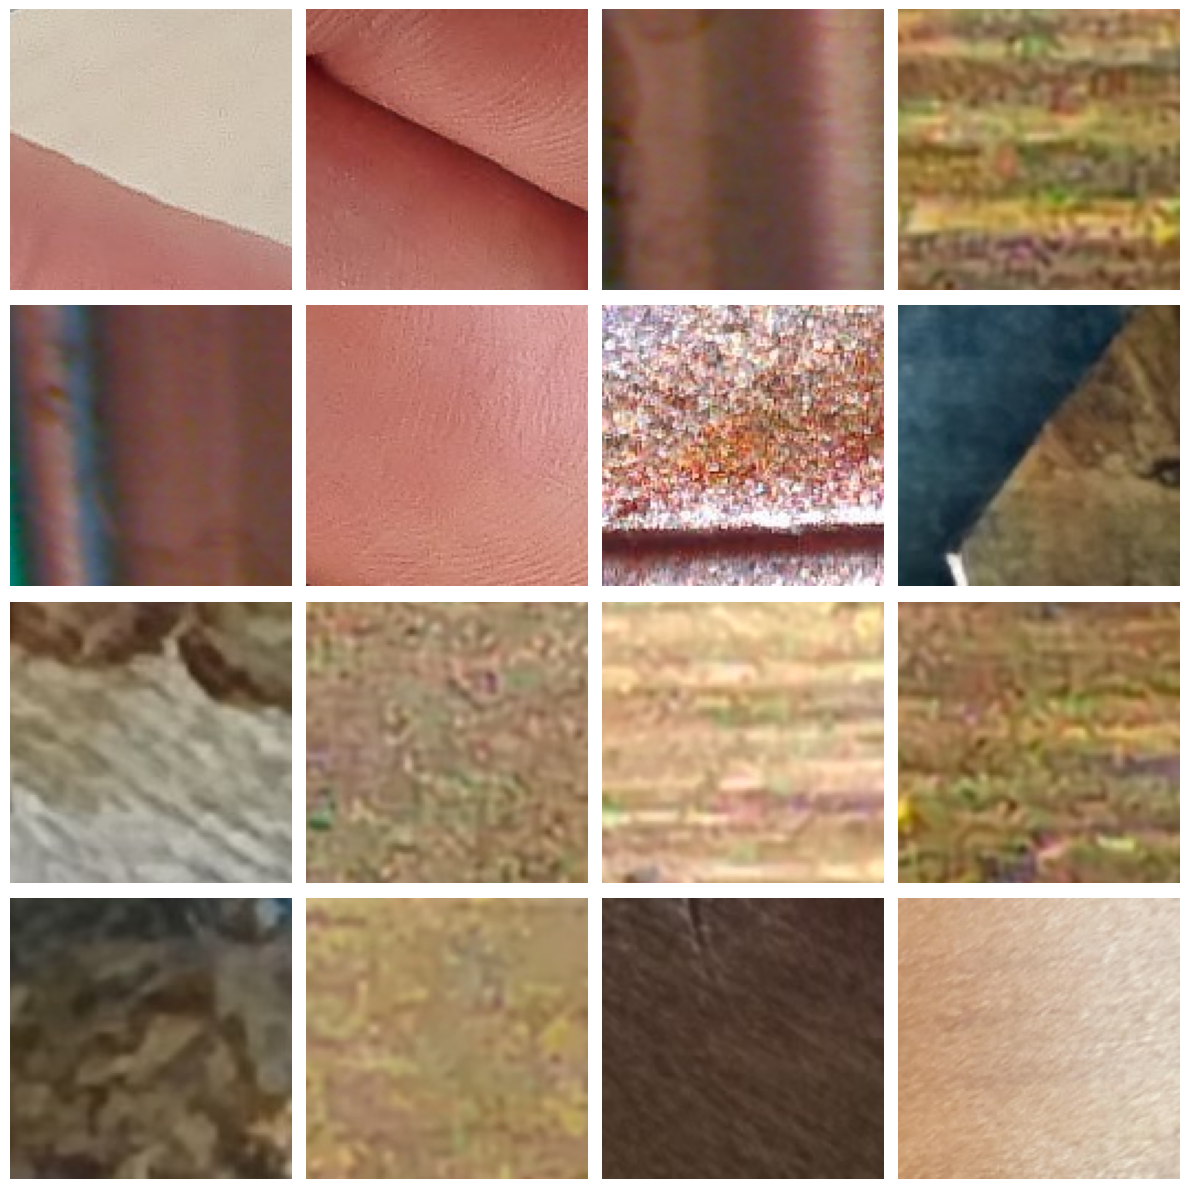

In [5]:
# Quick sanity check: visualize a few random patches
patch_paths = sorted(out_dir.glob("*.png"))
if patch_paths:
    sample = random.sample(patch_paths, min(16, len(patch_paths)))
    n = len(sample)
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, p in enumerate(sample, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(Image.open(p))
        plt.axis("off")
    plt.tight_layout()
else:
    print("No patches found. Try loosening thresholds or stride.")